In [1]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(1081)

In [7]:
df = df.drop_duplicates()
df.shape

(283726, 31)

In [8]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [9]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


In [10]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,94835.058093,47475.550607,0.0,54233.0,84711.0,139308.0,172792.0
1,473.0,80450.513742,48636.179973,406.0,41203.0,73408.0,129095.0,170348.0


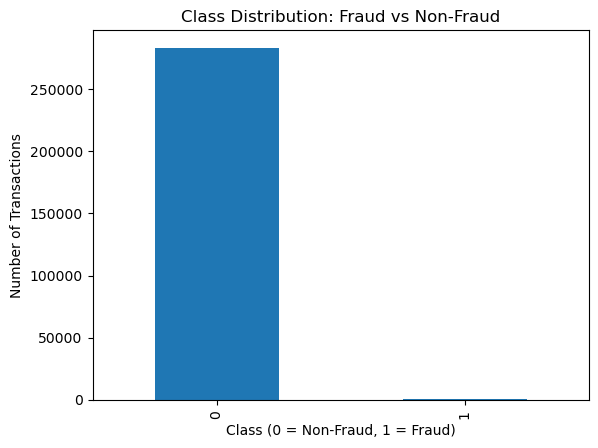

<Figure size 640x480 with 0 Axes>

In [42]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()
plt.savefig("fig_class_distribution.png", dpi=200, bbox_inches="tight")

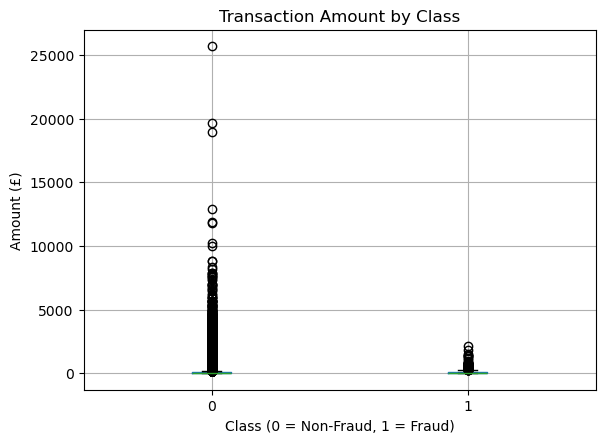

<Figure size 640x480 with 0 Axes>

In [44]:
df.boxplot(column="Amount", by="Class")
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Amount (£)")
plt.show()
plt.savefig("fig_amount_boxplot.png", dpi=200, bbox_inches="tight")

In [13]:
correlations = df.corr()["Class"].sort_values(ascending=False)
correlations

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

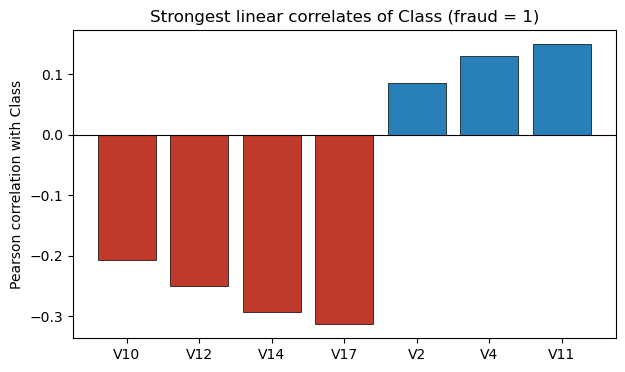

In [14]:
import matplotlib.pyplot as plt

# --- Step 1: get correlations and split by direction ---

# All feature correlations with Class, sign preserved, Class-with-itself dropped
correlations = df.corr()["Class"].drop("Class")

# Split into positives and negatives 
positives = correlations[correlations > 0].sort_values(ascending=False)
negatives = correlations[correlations < 0].sort_values(ascending=True)  # most negative first

# Keep top 3 positive and top 4 negative
top_positives = positives.head(3)
top_negatives = negatives.head(4)

# Combine into one Series, most-negative on the left through to most-positive on the right
# .iloc[::-1] reverses top_negatives so they run from -0.313 down to -0.207 (visually descending)
top_correlations = pd.concat([top_negatives.iloc[::-1], top_positives.iloc[::-1]])

# One colour per bar: red for negative, blue for positive
colors = ['#c0392b' if c < 0 else '#2980b9' for c in top_correlations]

# --- Step 2: create the figure ---

fig, ax = plt.subplots(figsize=(7, 4))

# --- Step 3: draw the bars ---

# Bar heights = correlation values (signs preserved)
ax.bar(top_correlations.index, top_correlations.values,
       color=colors, edgecolor='black', linewidth=0.5)

# Reference line at zero so positive vs negative direction is obvious
ax.axhline(0, color='black', linewidth=0.8)

# --- Step 4: labels and save ---

ax.set_ylabel('Pearson correlation with Class')
ax.set_title('Strongest linear correlates of Class (fraud = 1)')

plt.savefig('fig_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

df[["Amount", "Amount_scaled", "Time", "Time_scaled"]].head()

,Amount,Amount_scaled,Time,Time_scaled
0,149.62,0.244200,0.0,-1.996823
1,2.69,-0.342584,0.0,-1.996823
2,378.66,1.158900,1.0,-1.996802
3,123.50,0.139886,1.0,-1.996802
4,69.99,-0.073813,2.0,-1.996781


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class", "Amount", "Time"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((226980, 30), (56746, 30))

In [17]:
import pandas as pd

# Separate the training set into fraud and genuine rows
train_data = pd.concat([X_train, y_train], axis=1)
fraud = train_data[train_data['Class'] == 1]
genuine = train_data[train_data['Class'] == 0]

# Randomly sample genuine rows down to 1:1 with fraud rows
genuine_undersampled = genuine.sample(n=len(fraud), random_state=42)

# Recombine and shuffle
train_undersampled = pd.concat([fraud, genuine_undersampled]).sample(frac=1, random_state=42).reset_index(drop=True)

X_train_under = train_undersampled.drop('Class', axis=1)
y_train_under = train_undersampled['Class']

print(f"Undersampled training set: {len(X_train_under)} rows")
print(y_train_under.value_counts())

Undersampled training set: 756 rows
Class
0    378
1    378
Name: count, dtype: int64


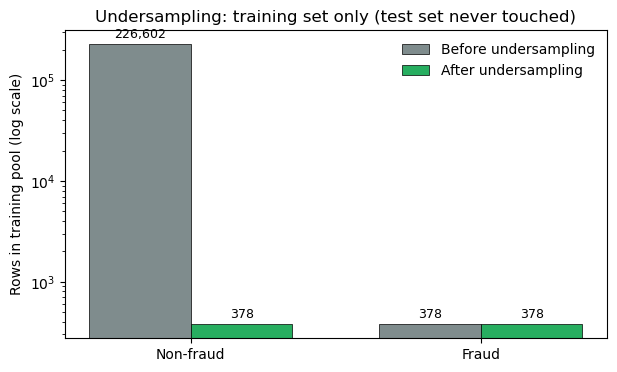

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- CHECK YOUR VARIABLE NAMES BEFORE RUNNING ---
# Replace these two with whatever you named yours in the undersampling cell.
# 'before' = your FULL training labels (~226,980 rows, pre-undersampling)
# 'after'  = your BALANCED training labels (756 rows, post-undersampling, 378/378)
y_train_before = y_train                # e.g. y_train, y_tr, y_train_full
y_train_after  = y_train_under          # e.g. y_train_under, y_balanced, y_train_bal

# --- Step 1: count non-fraud and fraud in each set ---

# .value_counts() returns how many of each class label there are
# .get(0, 0) fetches the count for class 0 (fallback = 0 if none exist — safety net)
before_nonfraud = y_train_before.value_counts().get(0, 0)
before_fraud    = y_train_before.value_counts().get(1, 0)
after_nonfraud  = y_train_after.value_counts().get(0, 0)
after_fraud     = y_train_after.value_counts().get(1, 0)

# Package into two lists that pair up: [non-fraud, fraud] for each set
before = [before_nonfraud, before_fraud]
after  = [after_nonfraud,  after_fraud]
categories = ['Non-fraud', 'Fraud']

# --- Step 2: prep the x-axis positions for grouped bars ---

# np.arange(2) makes [0, 1] — one x-position per category
x = np.arange(len(categories))

# width = how thick each bar is; 0.35 leaves a small gap between paired bars
width = 0.35

# --- Step 3: create the figure and draw two sets of bars side by side ---

fig, ax = plt.subplots(figsize=(7, 4))

# x - width/2 shifts the "before" bars slightly LEFT of each category tick
# x + width/2 shifts the "after"  bars slightly RIGHT of each category tick
b1 = ax.bar(x - width/2, before, width, label='Before undersampling',
            color='#7f8c8d', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + width/2, after,  width, label='After undersampling',
            color='#27ae60', edgecolor='black', linewidth=0.5)

# --- Step 4: switch y-axis to log scale ---

# On a linear scale the 378 bar would be invisible next to 226,583.
# Log scale lets us see both a huge and a tiny number on the same axis.
ax.set_yscale('log')

# --- Step 5: write the exact count above each bar so numbers are readable ---

# Loop through both sets of bars and place a text label just above each
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,   # x-position: middle of the bar
                h * 1.15,                          # y-position: 15% above bar top
                f'{int(h):,}',                     # text: number with thousands separator
                ha='center', fontsize=9)

# --- Step 6: labels, ticks, legend, save ---

ax.set_xticks(x)                                   # put category ticks at [0, 1]
ax.set_xticklabels(categories)                     # label them 'Non-fraud' / 'Fraud'
ax.set_ylabel('Rows in training pool (log scale)')
ax.set_title('Undersampling: training set only (test set never touched)')
ax.legend(frameon=False)

plt.savefig('fig_undersampling.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Train ONLY on the balanced, undersampled set
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_under, y_train_under)

# Predict on the ORIGINAL, untouched test set — real-world imbalance intact
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, digits=4))
print("AUC:", roc_auc_score(y_test, y_prob_lr))

[[55137  1514]
 [   12    83]]
              precision    recall  f1-score   support

           0     0.9998    0.9733    0.9864     56651
           1     0.0520    0.8737    0.0981        95

    accuracy                         0.9731     56746
   macro avg     0.5259    0.9235    0.5422     56746
weighted avg     0.9982    0.9731    0.9849     56746

AUC: 0.9558665290434786


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Train ONLY on the balanced, undersampled set
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_under, y_train_under)

# Predict on the ORIGINAL, untouched test set — real-world imbalance intact
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

[[55538  1113]
 [   14    81]]
              precision    recall  f1-score   support

           0     0.9997    0.9804    0.9900     56651
           1     0.0678    0.8526    0.1257        95

    accuracy                         0.9801     56746
   macro avg     0.5338    0.9165    0.5578     56746
weighted avg     0.9982    0.9801    0.9885     56746

AUC: 0.9716691023245746


In [21]:
from xgboost import XGBClassifier

# Train ONLY on the balanced, undersampled set
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_under, y_train_under)

# Predict on the ORIGINAL, untouched test set — real-world imbalance intact
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))

[[55004  1647]
 [   12    83]]
              precision    recall  f1-score   support

           0     0.9998    0.9709    0.9851     56651
           1     0.0480    0.8737    0.0910        95

    accuracy                         0.9708     56746
   macro avg     0.5239    0.9223    0.5381     56746
weighted avg     0.9982    0.9708    0.9836     56746

AUC: 0.9750390433020647


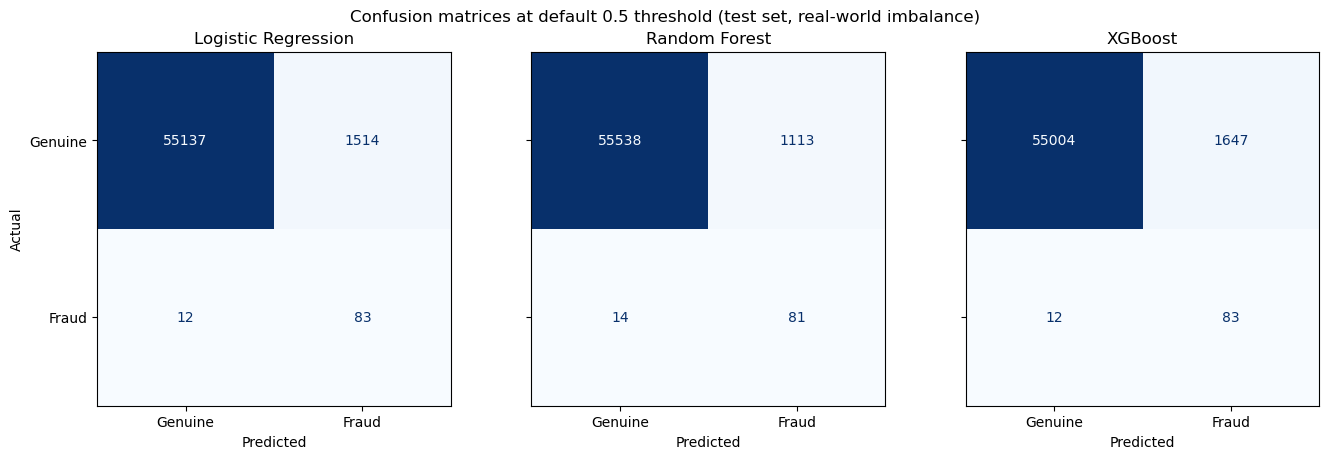

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Bundle the three models' predictions with their names in a list of tuples
# This lets us loop through and plot each without repeating the same block 3 times
models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("XGBoost",             y_pred_xgb),
]

# 1 row, 3 columns — three heatmaps side by side; sharey keeps them visually comparable
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

# Loop through each model, compute its confusion matrix, and draw a heatmap in one subplot
for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)                       # 2x2 grid: TN, FP, FN, TP
    disp = ConfusionMatrixDisplay(cm, display_labels=["Genuine", "Fraud"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax is axes[0] else "")           # y-label on leftmost only

plt.suptitle("Confusion matrices at default 0.5 threshold (test set, real-world imbalance)")
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

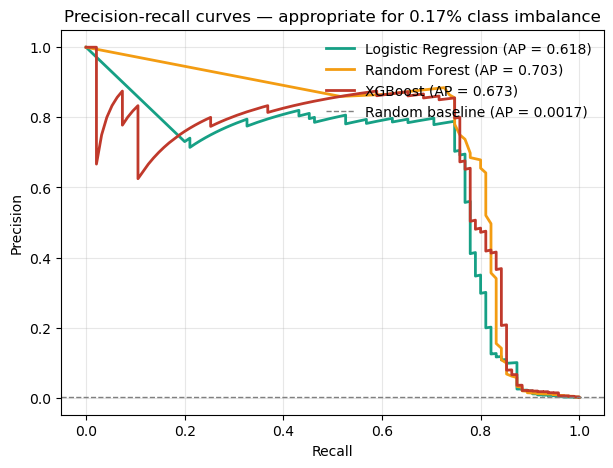

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# All three models plotted on ONE axis for direct comparison
fig, ax = plt.subplots(figsize=(7, 5))

# List of (name, raw probability array, colour) so we can loop cleanly
model_probs = [
    ("Logistic Regression", y_prob_lr,  "#16a085"),
    ("Random Forest",       y_prob_rf,  "#f39c12"),
    ("XGBoost",             y_prob_xgb, "#c0392b"),
]

for name, probs, colour in model_probs:
    # precision_recall_curve returns arrays of precision, recall at every possible threshold
    precision, recall, _ = precision_recall_curve(y_test, probs)
    # AP = area under the PR curve; a single-number summary equivalent to average precision
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, color=colour, linewidth=2, label=f"{name} (AP = {ap:.3f})")

# Baseline: a random classifier's PR curve is a horizontal line at the fraud prevalence
baseline = y_test.mean()  # ~0.0017 = 0.17% fraud
ax.axhline(baseline, color="grey", linestyle="--", linewidth=1,
           label=f"Random baseline (AP = {baseline:.4f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves — appropriate for 0.17% class imbalance")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.3)

plt.savefig("fig_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

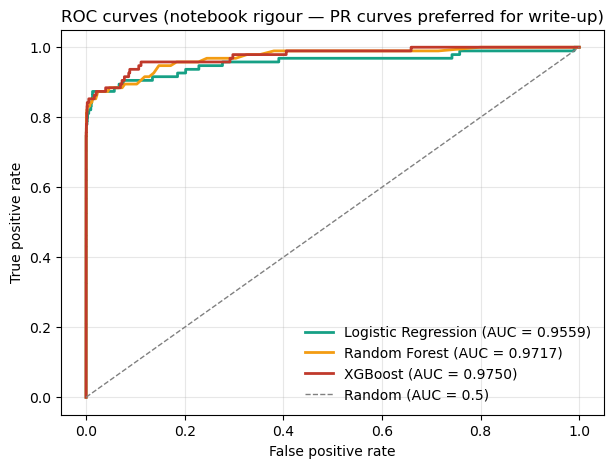

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(7, 5))

# Same list pattern as PR curves — loop through the three models
model_probs = [
    ("Logistic Regression", y_prob_lr,  "#16a085"),
    ("Random Forest",       y_prob_rf,  "#f39c12"),
    ("XGBoost",             y_prob_xgb, "#c0392b"),
]

for name, probs, colour in model_probs:
    # roc_curve returns false-positive rate and true-positive rate at every threshold
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=colour, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

# Diagonal reference: what a random classifier looks like
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="Random (AUC = 0.5)")

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves (notebook rigour — PR curves preferred for write-up)")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)

plt.savefig("fig_roc_curves.png", dpi=200, bbox_inches="tight")
plt.show()

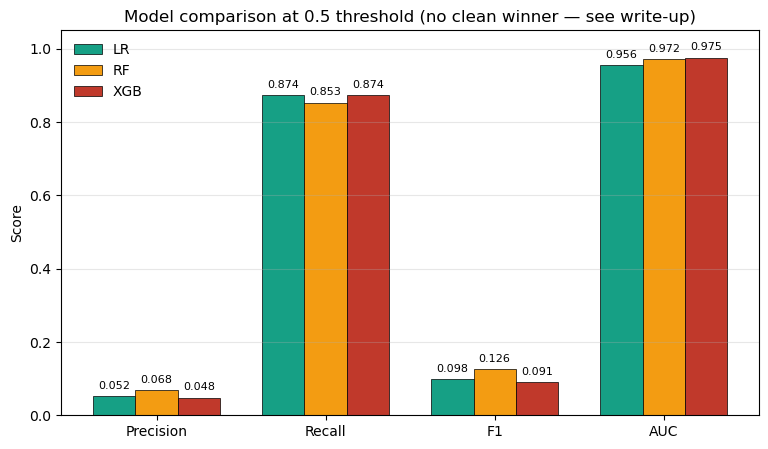

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Compute all four metrics for each model at the default 0.5 threshold
metrics = {}
for name, y_pred, y_prob in [
    ("LR",  y_pred_lr,  y_prob_lr),
    ("RF",  y_pred_rf,  y_prob_rf),
    ("XGB", y_pred_xgb, y_prob_xgb),
]:
    metrics[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "AUC":       roc_auc_score(y_test, y_prob),
    }

# Prep for grouped bar chart: metric names on x-axis, one group of 3 bars per metric
metric_names = ["Precision", "Recall", "F1", "AUC"]
models = ["LR", "RF", "XGB"]
colours = ["#16a085", "#f39c12", "#c0392b"]

# Bar positioning: 4 metric groups, each with 3 model bars side by side
x = np.arange(len(metric_names))                 # [0, 1, 2, 3] — one x-position per metric
width = 0.25                                     # thickness of each individual bar

fig, ax = plt.subplots(figsize=(9, 5))

# One loop iteration per model — offset each model's bars left/centre/right within each metric group
for i, (model, colour) in enumerate(zip(models, colours)):
    values = [metrics[model][m] for m in metric_names]
    offset = (i - 1) * width                     # -width, 0, +width for the three models
    bars = ax.bar(x + offset, values, width, label=model, color=colour,
                  edgecolor="black", linewidth=0.5)
    # Print value above each bar
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f"{v:.3f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Model comparison at 0.5 threshold (no clean winner — see write-up)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.savefig("fig_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [25]:
# Brier score = average squared difference between predicted probability and actual outcome (0 or 1)
# Lower score = better calibrated probabilities; 0 = perfect, ~0.25 = random guessing
from sklearn.metrics import brier_score_loss

# Using y_prob_* saved earlier from predict_proba() in Steps 2-4 — this is exactly why we saved them
brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)
brier_xgb = brier_score_loss(y_test, y_prob_xgb)

# Comparing all three side by side — expect all to look "small," what matters is relative to AUC quality
print("Logistic Regression Brier score:", brier_lr)
print("Random Forest Brier score:", brier_rf)
print("XGBoost Brier score:", brier_xgb)

Logistic Regression Brier score: 0.0250436732435849
Random Forest Brier score: 0.027886802594015436
XGBoost Brier score: 0.02162409835792928


In [26]:
# Dal Pozzolo et al. (2015): correction formula to undo the probability distortion caused by undersampling
# beta = fraction of the genuine (majority) class KEPT during undersampling — smaller beta = stronger distortion
# Derived directly from Step 1's variables (fraud, genuine) so it's exact, not estimated
beta = len(fraud) / len(genuine)
print("Undersampling rate (beta):", beta)

# The correction formula itself, applied to any probability array
def correct_probability(p_s, beta):
    return (beta * p_s) / (beta * p_s - p_s + 1)

# Apply it to each model's saved fraud-probability column (from Steps 2-4)
y_prob_lr_corrected = correct_probability(y_prob_lr, beta)
y_prob_rf_corrected = correct_probability(y_prob_rf, beta)
y_prob_xgb_corrected = correct_probability(y_prob_xgb, beta)

# Recompute Brier score on the CORRECTED probabilities — compare directly against Step 6's uncorrected scores
brier_lr_corrected = brier_score_loss(y_test, y_prob_lr_corrected)
brier_rf_corrected = brier_score_loss(y_test, y_prob_rf_corrected)
brier_xgb_corrected = brier_score_loss(y_test, y_prob_xgb_corrected)

print("Logistic Regression Brier score (corrected):", brier_lr_corrected)
print("Random Forest Brier score (corrected):", brier_rf_corrected)
print("XGBoost Brier score (corrected):", brier_xgb_corrected)

Undersampling rate (beta): 0.001668122964492811
Logistic Regression Brier score (corrected): 0.0012489261354328154
Random Forest Brier score (corrected): 0.0008885908505609545
XGBoost Brier score (corrected): 0.000708762476639596


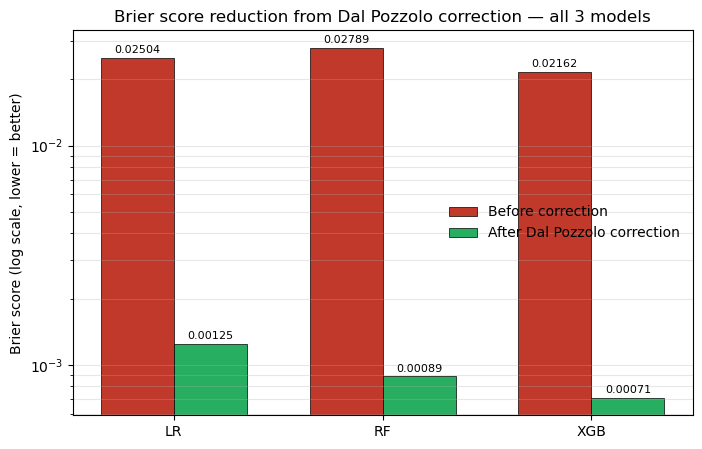

In [39]:
import matplotlib.pyplot as plt
import numpy as np

models = ["LR", "RF", "XGB"]
before = [brier_lr,           brier_rf,           brier_xgb]
after  = [brier_lr_corrected, brier_rf_corrected, brier_xgb_corrected]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, before, width, label="Before correction", color="#c0392b", edgecolor="black", linewidth=0.5)
b2 = ax.bar(x + width/2, after,  width, label="After Dal Pozzolo correction", color="#27ae60", edgecolor="black", linewidth=0.5)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.05,
                f"{h:.5f}", ha="center", fontsize=8)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Brier score (log scale, lower = better)")
ax.set_title("Brier score reduction from Dal Pozzolo correction — all 3 models")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3, which="both")

plt.savefig("fig_brier_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

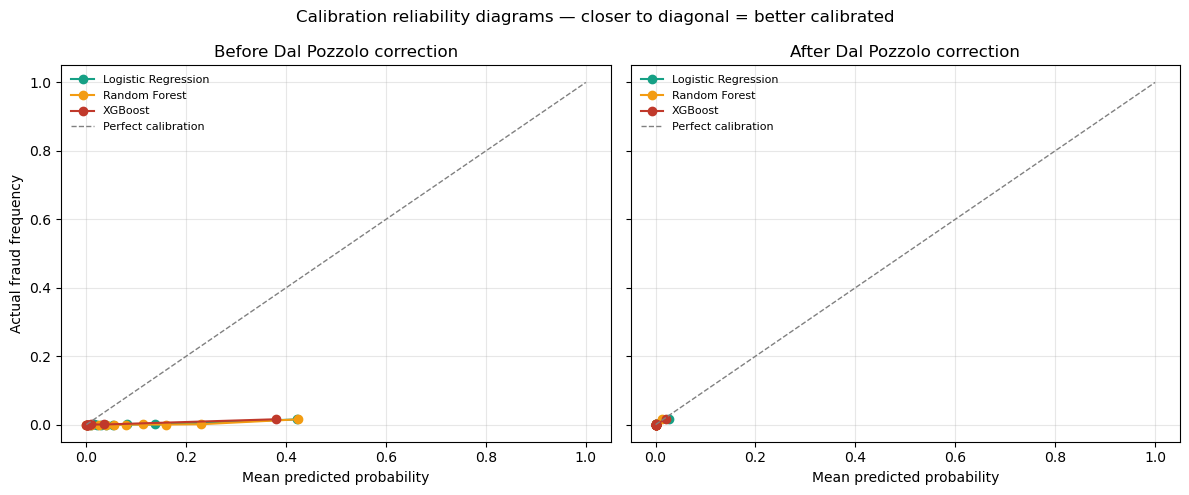

In [41]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Two subplots: left = before correction, right = after correction
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# List of (name, before probs, after probs, colour)
model_probs = [
    ("Logistic Regression", y_prob_lr,  y_prob_lr_corrected,  "#16a085"),
    ("Random Forest",       y_prob_rf,  y_prob_rf_corrected,  "#f39c12"),
    ("XGBoost",             y_prob_xgb, y_prob_xgb_corrected, "#c0392b"),
]

# Loop through models and draw each on both subplots
for name, probs_before, probs_after, colour in model_probs:
    # calibration_curve bins the predictions and returns:
    #   fraction_positives = actual fraud rate in each bin
    #   mean_predicted     = mean predicted probability in each bin
    # strategy='quantile' bins by data density — better for skewed prediction distributions
    frac_before, mean_before = calibration_curve(y_test, probs_before, n_bins=10, strategy="quantile")
    frac_after,  mean_after  = calibration_curve(y_test, probs_after,  n_bins=10, strategy="quantile")

    axes[0].plot(mean_before, frac_before, marker="o", color=colour, label=name)
    axes[1].plot(mean_after,  frac_after,  marker="o", color=colour, label=name)

# Diagonal reference line = perfect calibration
for ax in axes:
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1, label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", fontsize=8, frameon=False)

axes[0].set_ylabel("Actual fraud frequency")
axes[0].set_title("Before Dal Pozzolo correction")
axes[1].set_title("After Dal Pozzolo correction")

plt.suptitle("Calibration reliability diagrams — closer to diagonal = better calibrated")
plt.tight_layout()
plt.savefig("fig_calibration_reliability.png", dpi=200, bbox_inches="tight")
plt.show()

In [27]:
# Peek at the first 10 raw (uncorrected) XGBoost probabilities and their real answers,
# side by side — this makes the "distortion" concrete instead of abstract
import pandas as pd

peek = pd.DataFrame({
    "actual_label": y_test.values[:10],
    "raw_probability": y_prob_xgb[:10],
    "corrected_probability": y_prob_xgb_corrected[:10]
})
print(peek)

   actual_label  raw_probability  corrected_probability
0             0         0.000265           4.415001e-07
1             0         0.000678           1.130976e-06
2             0         0.048444           8.491692e-05
3             0         0.000394           6.576877e-07
4             0         0.090189           1.653326e-04
5             0         0.002644           4.421784e-06
6             0         0.001129           1.885680e-06
7             0         0.000152           2.536790e-07
8             0         0.272085           6.231326e-04
9             0         0.000138           2.295984e-07


In [28]:
# X_test keeps the original row numbers from df (train_test_split doesn't reset the index),
# so we can use those same row numbers to pull the REAL, unscaled £ amount for each test transaction
test_amounts = df.loc[X_test.index, "Amount"]

# Expected loss = corrected probability of fraud x the real transaction amount
# Using XGBoost's corrected probabilities here as the example — best AUC and best corrected calibration of the three
expected_loss = y_prob_xgb_corrected * test_amounts

# Total expected loss across the whole test set — this is your headline cost-proxy figure
print("Total expected loss (test set):", expected_loss.sum())

# The highest-risk individual transactions, ranked — useful to sanity-check the numbers look sensible
print(expected_loss.sort_values(ascending=False).head(10))

Total expected loss (test set): 34217.60355658401
274771    17622.601115
195218     1699.715477
6971       1363.582527
95597      1176.816314
145090      668.451258
44001       662.156912
215132      564.833015
149874      541.639654
94218       535.914556
212644      526.580071
Name: Amount, dtype: float64


In [29]:
# The single largest expected-loss transaction is driving over half the total — worth verifying what it actually is
top_index = 274771

# Was this transaction actually fraud (1) or genuine (0)? This tells us if the model's concern here is justified
print("Actual label (1=fraud, 0=genuine):", y_test.loc[top_index])

# The real transaction amount behind this estimate
print("Transaction amount:", test_amounts.loc[top_index])

# The model's corrected fraud probability for this specific transaction
row_position = X_test.index.get_loc(top_index)
print("XGBoost corrected fraud probability:", y_prob_xgb_corrected[row_position])

Actual label (1=fraud, 0=genuine): 0
Transaction amount: 25691.16
XGBoost corrected fraud probability: 0.68594027


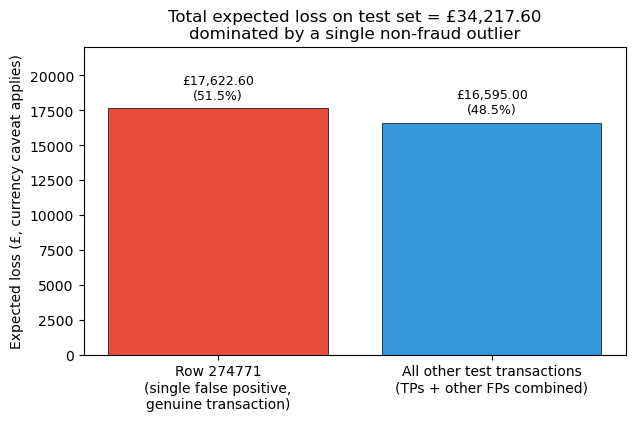

In [36]:
import matplotlib.pyplot as plt

# --- Step 1: identify the single most costly transaction and split the total ---

# .idxmax() returns the index label (row number) with the largest expected loss — row 274771
top_row_id = expected_loss.idxmax()

# .max() returns that row's actual expected-loss value
top_row_cost = expected_loss.max()

# Everything else = total minus that single row's contribution
rest_cost = expected_loss.sum() - top_row_cost

# --- Step 2: prep bar values ---

labels = [f"Row {top_row_id}\n(single false positive,\ngenuine transaction)",
          "All other test transactions\n(TPs + other FPs combined)"]
values = [top_row_cost, rest_cost]
colors = ["#e74c3c", "#3498db"]   # red = the dominant outlier, blue = everything else

# --- Step 3: draw the bars ---

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)

# --- Step 4: value + percentage labels above each bar ---

total = sum(values)
for bar, v in zip(bars, values):
    pct = 100 * v / total
    ax.text(bar.get_x() + bar.get_width()/2,
            v + total * 0.02,
            f"£{v:,.2f}\n({pct:.1f}%)",
            ha="center", fontsize=9)

# --- Step 5: labels, limits, save ---

ax.set_ylabel("Expected loss (£, currency caveat applies)")
ax.set_title(f"Total expected loss on test set = £{total:,.2f}\ndominated by a single non-fraud outlier")
ax.set_ylim(0, max(values) * 1.25)

plt.savefig("fig_cost_dominance.png", dpi=200, bbox_inches="tight")
plt.show()

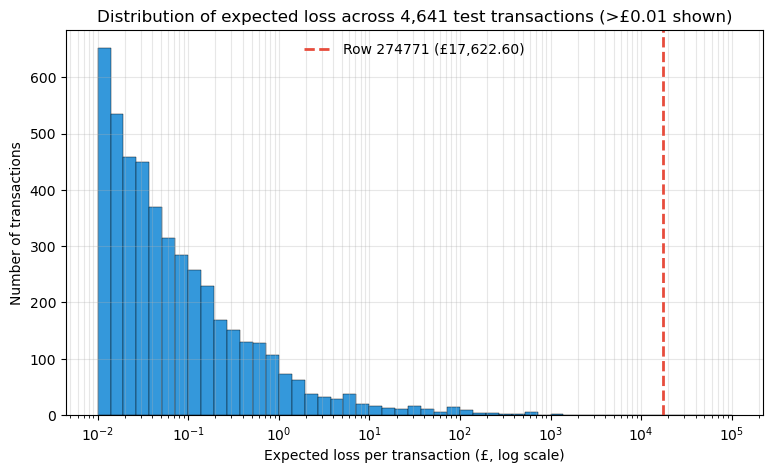

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Only plot transactions with non-negligible expected loss (>£0.01) so tiny values don't dominate the axis
significant_losses = expected_loss[expected_loss > 0.01]

fig, ax = plt.subplots(figsize=(9, 5))

# Log-scale x-axis: expected losses span many orders of magnitude (fractions of £ up to £17k)
ax.hist(significant_losses, bins=np.logspace(-2, 5, 50), color="#3498db", edgecolor="black", linewidth=0.3)
ax.set_xscale("log")

# Mark row 274771 with a red vertical line — visualise how far it sits from the mass of the distribution
ax.axvline(expected_loss.loc[274771], color="#e74c3c", linewidth=2, linestyle="--",
           label=f"Row 274771 (£{expected_loss.loc[274771]:,.2f})")

ax.set_xlabel("Expected loss per transaction (£, log scale)")
ax.set_ylabel("Number of transactions")
ax.set_title(f"Distribution of expected loss across {len(significant_losses):,} test transactions (>£0.01 shown)")
ax.legend(frameon=False)
ax.grid(alpha=0.3, which="both")

plt.savefig("fig_expected_loss_dist.png", dpi=200, bbox_inches="tight")
plt.show()

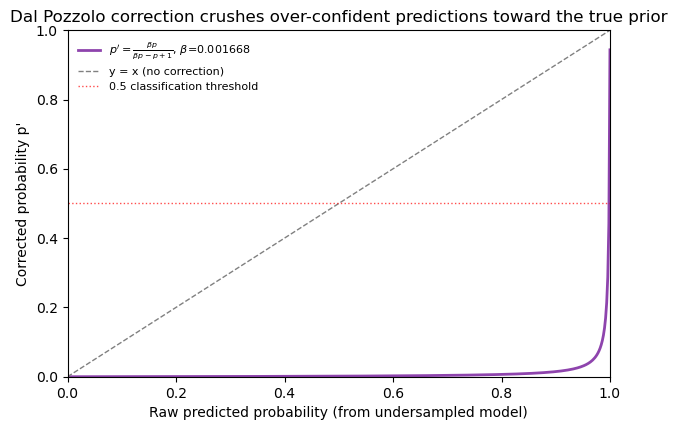

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: define β (the undersampling ratio) ---
# β = non-fraud kept during undersampling / non-fraud originally in training set
beta = 378 / 226602

# --- Step 2: build a raw-probability axis from 0 to 1 ---
# 500 evenly-spaced points, avoiding exact 0/1 for numerical safety
p_raw = np.linspace(0.001, 0.9999, 500)

# --- Step 3: apply the Dal Pozzolo formula element-wise ---
# p' = (β·p) / (β·p − p + 1)
p_corrected = (beta * p_raw) / (beta * p_raw - p_raw + 1)

# --- Step 4: draw the curve ---
fig, ax = plt.subplots(figsize=(7, 4.5))

# Main correction curve
ax.plot(p_raw, p_corrected, color='#8e44ad', linewidth=2,
        label=r"$p' = \frac{\beta p}{\beta p - p + 1}$, $\beta$=%.6f" % beta)

# Diagonal reference — where you'd sit with no correction
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1,
        label='y = x (no correction)')

# Horizontal line at 0.5 — default classification threshold
ax.axhline(0.5, color='red', linestyle=':', linewidth=1, alpha=0.7,
           label='0.5 classification threshold')

# --- Step 5: labels, limits, legend, save ---
ax.set_xlabel('Raw predicted probability (from undersampled model)')
ax.set_ylabel("Corrected probability p'")
ax.set_title('Dal Pozzolo correction crushes over-confident predictions toward the true prior')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=8, frameon=False)

plt.savefig('fig_dalpozzolo_methodology.png', dpi=200, bbox_inches='tight')
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Split the ORIGINAL training pool (226,980 rows) into 5 folds, preserving the fraud ratio in each —
# "Stratified" matters here because fraud is so rare a plain random split could leave one fold nearly empty of it
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store each model's AUC score from every fold here, so we can average them at the end
auc_scores = {"Logistic Regression": [], "Random Forest": [], "XGBoost": []}

# .split() hands us 5 different (train_idx, val_idx) pairs — row positions within X_train/y_train only
for fold_num, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):

    # Slice out THIS fold's training portion and validation portion from the training pool
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Repeat the EXACT SAME undersampling logic from Step 1, but only on this fold's training slice —
    # each fold gets its own fresh balanced set, mirroring your real methodology instead of skipping it
    fold_data = pd.concat([X_fold_train, y_fold_train], axis=1)
    fold_fraud = fold_data[fold_data["Class"] == 1]
    fold_genuine = fold_data[fold_data["Class"] == 0]
    fold_genuine_under = fold_genuine.sample(n=len(fold_fraud), random_state=42)
    fold_balanced = pd.concat([fold_fraud, fold_genuine_under]).sample(frac=1, random_state=42)

    X_fold_train_under = fold_balanced.drop("Class", axis=1)
    y_fold_train_under = fold_balanced["Class"]

    # Fresh copies of all 3 models each fold, so nothing carries over between folds
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    }

    for name, model in models.items():
        model.fit(X_fold_train_under, y_fold_train_under)
        # Evaluate on this fold's held-out validation slice — real-world imbalance intact, untouched by undersampling
        val_prob = model.predict_proba(X_fold_val)[:, 1]
        auc_scores[name].append(roc_auc_score(y_fold_val, val_prob))

    print(f"Fold {fold_num} complete")

# Report mean AUC and standard deviation across all 5 folds, per model — low std = stable, trustworthy result
for name, scores in auc_scores.items():
    print(f"{name}: mean AUC = {np.mean(scores):.4f}, std = {np.std(scores):.4f}")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete
Logistic Regression: mean AUC = 0.9809, std = 0.0078
Random Forest: mean AUC = 0.9775, std = 0.0108
XGBoost: mean AUC = 0.9778, std = 0.0085


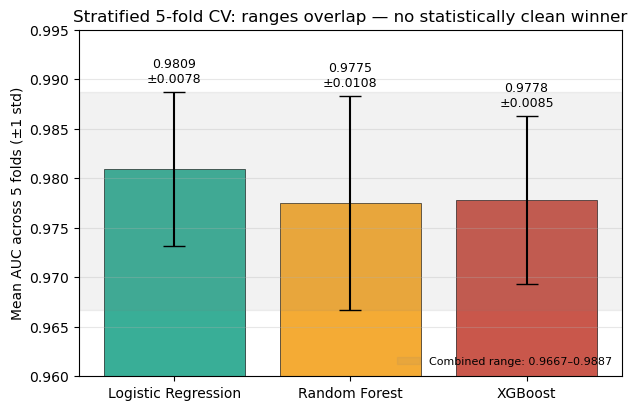

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# auc_scores is the dict from your CV loop: {"Logistic Regression": [...5 scores...], "Random Forest": [...], "XGBoost": [...]}
model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
means = [np.mean(auc_scores[name]) for name in model_names]
stds  = [np.std(auc_scores[name])  for name in model_names]

colours = ["#16a085", "#f39c12", "#c0392b"]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(model_names))

# yerr adds error bars (±1 std); capsize puts small caps on the ends
ax.bar(x, means, yerr=stds, capsize=8, color=colours, edgecolor="black", linewidth=0.5, alpha=0.85,
       error_kw=dict(elinewidth=1.5, ecolor="black"))

# Annotate each bar with its mean ± std
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.001, f"{m:.4f}\n±{s:.4f}", ha="center", fontsize=9)

# Shade the combined overlap range across all three models — makes "no clean winner" visually unmissable
lo = min(m - s for m, s in zip(means, stds))
hi = max(m + s for m, s in zip(means, stds))
ax.axhspan(lo, hi, color="grey", alpha=0.1, label=f"Combined range: {lo:.4f}–{hi:.4f}")

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Mean AUC across 5 folds (±1 std)")
ax.set_title("Stratified 5-fold CV: ranges overlap — no statistically clean winner")
ax.set_ylim(0.96, 0.995)
ax.legend(loc="lower right", fontsize=8, frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.savefig("fig_cv_overlap.png", dpi=200, bbox_inches="tight")
plt.show()

In [45]:
import os
[f for f in os.listdir() if f.endswith('.png')]

['fig_confusion_matrices.png',
 'fig_expected_loss_dist.png',
 'fig_amount_boxplot.png',
 'fig_calibration_reliability.png',
 'fig_roc_curves.png',
 'fig_pr_curves.png',
 'fig_correlation.png',
 'fig_dalpozzolo.png',
 'fig_undersampling.png',
 'fig_brier_comparison.png',
 'fig_dalpozzolo_methodology.png',
 'fig_metric_comparison.png',
 'fig_cost_dominance.png',
 'fig_class_distribution.png',
 'fig_cv_overlap.png']